# **Classification d'Activités Humaines**

## **Importation des librairies**

In [1]:
import numpy as np
import pandas as pd
import os

import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import skew, kurtosis
from statsmodels.tsa.ar_model import AutoReg
from scipy.fft import fft, fftfreq

## **Phase 1 : Chargement des Données**

L'objectif est de consolider les 9 fichiers de données pour créer notre jeu de données principal (les 347 individus).

- **Chargement des Données** : qui va consister à importer les 9 fichiers .txt (accm_x, accm_y, etc.) qui sont des tableaux de taille $347 \times 128$.
- **Création du Jeu de Données 3D (avec les 03 dimensions)** : qui va consister à structurer les données dans un seul objet de dimension $347 \times 128 \times 9$ (Fenêtres $\times$ Temps $\times$ Variables).


In [2]:
def load_and_structure_data(data_folder, file_names, nb_fichiers):
    """
    Charge les 9 fichiers de données de séries temporelles depuis un dossier
    spécifié et les structure en un tableau NumPy 3D.

    """
    if len(file_names) != nb_fichiers:
        print(f"ERREUR : La fonction attend exactement {nb_fichiers} noms de fichiers.")
        return None, None

    variable_names = [name.split('.')[0] for name in file_names]
    data_list = []

    print(f"Étape 1/2 : Début du chargement de {nb_fichiers} fichiers depuis : '{data_folder}'")

    # 1. Chargement des fichiers (Fenêtre x Temps)
    for file_name in file_names:
        file_path = os.path.join(data_folder, file_name)

        try:
            # Lecture du fichier (séparateur d'espace/tabulation, pas d'en-tête)
            df = pd.read_csv(file_path, sep=r'\s+', header=None)
            data_list.append(df)
        except FileNotFoundError:
            print(f"ERREUR : Fichier {file_path} introuvable.")
            return None, None
        except Exception as e:
            print(f"ERREUR lors de la lecture de {file_path} : {e}")
            return None, None

    # 2. Création du Jeu de Données 3D (Fenêtres x Temps x Variables)
    print("Étape 2/2 : Structuration en tableau 3D...")

    # Empilons les DataFrames. Structure initiale : (Variables, Fenêtres, Temps)
    data_3d_temp = np.array([df.values for df in data_list])

    # Transposons pour obtenir la structure désirée : (Fenêtres, Temps, Variables)
    data_3d = data_3d_temp.transpose((1, 2, 0))

    print(f"✅ Succès : Données structurées en {data_3d.shape}.")
    return data_3d, variable_names

#### **Appel de la fonction pour la construction de notre jeu de données**

In [3]:
dossier = '/content/drive/MyDrive/data_human_activities'
noms_fichiers = [
    'accm_x.txt', 'accm_y.txt', 'accm_z.txt',
    'acce_x.txt', 'acce_y.txt', 'acce_z.txt',
    'vit_x.txt', 'vit_y.txt', 'vit_z.txt'
]
nb_fichiers = len(noms_fichiers)


data_raw, variable_names = load_and_structure_data(dossier, noms_fichiers, nb_fichiers)

if data_raw is not None:
    print(f"\nLa variable 'data_raw' contient le jeu de données 3D et 'variable_names' la liste des noms des variables.")

Étape 1/2 : Début du chargement de 9 fichiers depuis : '/content/drive/MyDrive/data_human_activities'
Étape 2/2 : Structuration en tableau 3D...
✅ Succès : Données structurées en (347, 128, 9).

La variable 'data_raw' contient le jeu de données 3D et 'variable_names' la liste des noms des variables.


### **Tableau récapitulatif de notre jeu de données**

| Dimension | Taille | Ce que l'index représente | Rôle dans le projet |
| :---: | :---: | :--- | :--- |
| **Axe 1** | **347** | L'**individu** (la **Fenêtre Temporelle**). | Index 0 = Fenêtre n°1. |
| **Axe 2** | **128** | Le **Temps** (Les mesures successives). | Index 0 = La première mesure de cette fenêtre (t=0). |
| **Axe 3** | **9** | La **Variable** (accm\_x, accm\_y, vit\_z, etc.). | Index 0 = La première variable (`accm_x`). |

#### **Affichage de la deuxième fenêtre**

In [4]:
# 1. Affichage de la forme
print(f"Forme du tableau de données : {data_raw.shape}")

Forme du tableau de données : (347, 128, 9)


In [5]:
# 2. Affichage d'un extrait numérique

# Affichage des 128 mesures (Temps) de la 2e fenêtre (Fenêtre 1)
# pour la première variable (accm_x, indice 0)

fenetre_1_accm_x = data_raw[1, :, 0]

print(f"\nExtrait de la Fenêtre 2 (indice 0) (Variable {variable_names[0]}):")
print("\n")
print(fenetre_1_accm_x)


Extrait de la Fenêtre 2 (indice 0) (Variable accm_x):


[1.018851 1.02238  1.020781 1.020218 1.021344 1.020522 1.01979  1.019216
 1.018307 1.017996 1.017932 1.018121 1.018305 1.018458 1.018201 1.017129
 1.017814 1.0188   1.017601 1.01797  1.018489 1.017787 1.019167 1.019789
 1.019462 1.020433 1.021189 1.021903 1.021936 1.02055  1.018878 1.018548
 1.017389 1.015021 1.01931  1.024606 1.021863 1.020201 1.020573 1.018729
 1.01936  1.019954 1.018969 1.019633 1.019553 1.019179 1.019695 1.019145
 1.018516 1.017926 1.01778  1.018917 1.020606 1.022583 1.020981 1.018065
 1.019638 1.020017 1.018766 1.019815 1.01929  1.018445 1.019372 1.021171
 1.023127 1.021882 1.019178 1.015861 1.012893 1.016451 1.020331 1.020266
 1.021759 1.018649 1.013117 1.016167 1.018977 1.016653 1.017782 1.020528
 1.021877 1.022096 1.020731 1.020761 1.020405 1.020213 1.021675 1.019989
 1.017997 1.017391 1.017994 1.021661 1.022348 1.020336 1.019066 1.018882
 1.020013 1.018262 1.017474 1.018954 1.019628 1.022794 1.024238 1.0

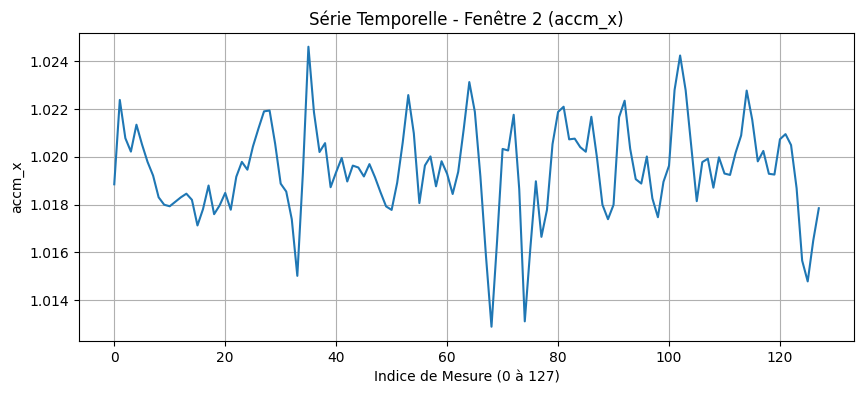

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(fenetre_1_accm_x)
plt.title(f'Série Temporelle - Fenêtre 2 ({variable_names[0]})')
plt.xlabel('Indice de Mesure (0 à 127)')
plt.ylabel(variable_names[0])
plt.grid(True)
plt.savefig('/content/drive/MyDrive/data_human_activities/fenetre_r_2_accm_x.png')
plt.show()

#### **Affichage de toutes les variables de la Fenêtre 2**

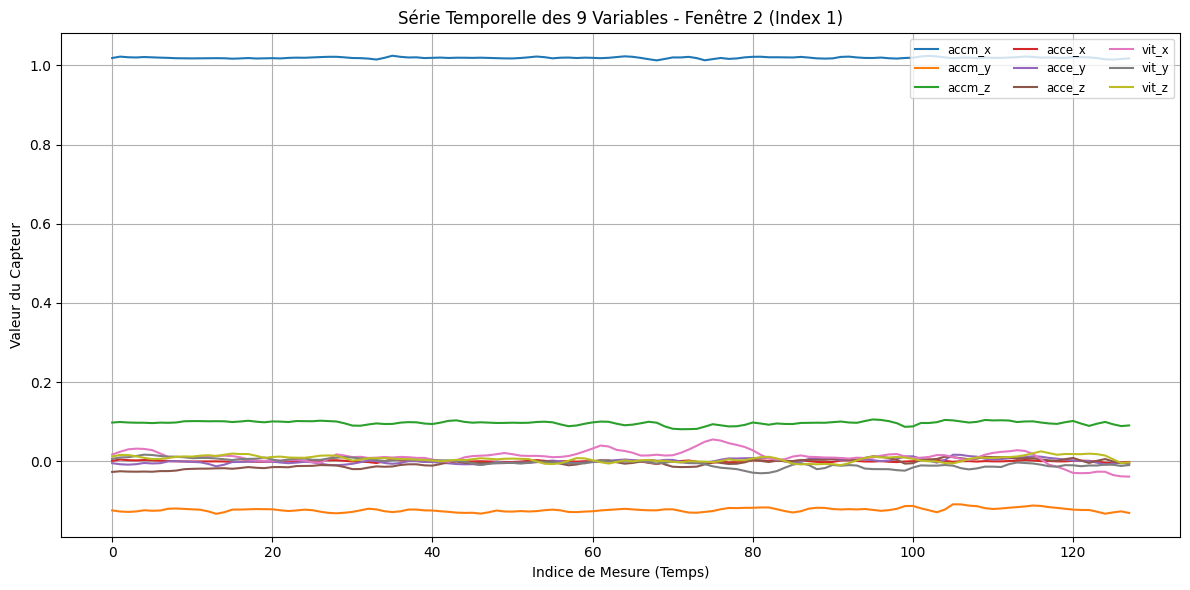

In [7]:
# 1. Extraction des données pour la Fenêtre 2 (Index 1)
# La tranche [1, :, :] extrait toutes les 128 mesures (:) pour les 9 variables (:)
fenetre_data = data_raw[1, :, :]

# 2. Création de la figure
plt.figure(figsize=(12, 6))

# 3. Tracé des 9 variables
plt.plot(fenetre_data, label=variable_names)

# 4. Configuration des labels et du titre
plt.title('Série Temporelle des 9 Variables - Fenêtre 2 (Index 1)')
plt.xlabel('Indice de Mesure (Temps)')
plt.ylabel('Valeur du Capteur')
plt.grid(True)
plt.legend(loc='upper right', fontsize='small', ncol=3) # Ajout de la légende
plt.tight_layout() # Ajustement pour s'assurer que les labels et la légende sont visibles
plt.savefig('/content/drive/MyDrive/data_human_activities/fenetre_2_all_variables.png')
plt.show()

#### **Chargement des données de test**

In [8]:
dossier = '/content/drive/MyDrive/data_human_activities'

# Chargement des labels vrais
labels_reels = pd.read_csv(f'{dossier}/lab.txt', header=None, sep=r'\s+')
labels_reels = labels_reels.squeeze()  # Convertit en Series si une seule colonne

print("✅ Fichier lab.txt chargé.")
print(labels_reels.head())
print(f'On a {len(labels_reels)} vraies classes dans le fichier label.txt')


✅ Fichier lab.txt chargé.
0    5
1    5
2    5
3    5
4    5
Name: 0, dtype: int64
On a 347 vraies classes dans le fichier label.txt


In [77]:
print(labels_reels.value_counts())

0
1    95
5    53
2    53
6    50
3    49
4    47
Name: count, dtype: int64


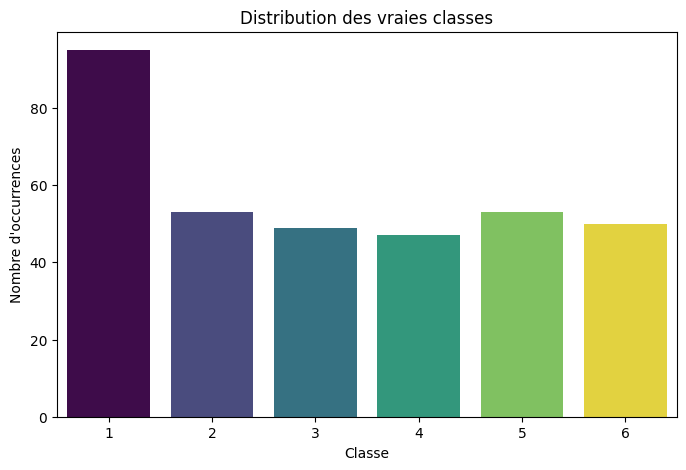

In [75]:
# --- Visualisation de la distribution ---
plt.figure(figsize=(8, 5))
sns.countplot(x=labels_reels, hue=labels_reels, palette="viridis", legend=False)

plt.title("Distribution des vraies classes")
plt.xlabel("Classe")
plt.ylabel("Nombre d'occurrences")

# Enregistrement de l'image
plt.savefig("/content/drive/MyDrive/data_human_activities/distribution_classes.png")
plt.show()

## **Phase 2 : Extraction de Caractéristiques**

Jusqu'à présent, chaque individu (fenêtre temporelle) est un objet **complexe** de dimensions $128 \times 9$. Si on utilise une approche de série temporelle directe directement sur cet objet, l'algorithme comparerait les **1152 valeurs** ($128 \times 9$) de la fenêtre 1 à celles de la Fenêtre 2 par exemple, ce qui est inefficace en haute dimension.

L'objectif de cette phase est de **résumer** la série temporelle de **128 points** pour chaque variable en **un petit nombre de valeurs significatives** : on veut donc créer une seule colonne de caractéristiques pour chaque combinaison (Variable + Type de Caractéristique).

Le nombre total de caractéristiques est calculé ainsi :

$$\text{Nombre total de caractéristiques} = (\text{Nombre de variables}) \times (\text{Nombre de types de caractéristiques par variable})$$

* **AVANT la Phase 2 :** Fenêtre 1 $\rightarrow$ (Série de 128 mesures pour accm\_x, Série de 128 mesures pour accm\_y, ...)
* **APRÈS la Phase 2 :** Fenêtre 1 $\rightarrow$ (Moyenne accm\_x, Variance accm\_x, Coeff AR accm\_x, ...)

On va opter pour ces 8 caractéristiques :  
- **Statistiques de base** : Moyenne, Écart-type (Variance), Min, Max.
- **Moments d'ordre $p$** : Skewness (Ordre 3), Kurtosis (Ordre 4).
- **Coefficients de Modèle** : 1er Coefficient AR (pour capturer la dynamique).
- **Coefficients de Fréquence** : Amplitude de la composante fréquentielle principale (issue de la Transformée de Fourier).

En faisant cela pour les 9 variables, on transforme le tableau $347 \times 128 \times 9$ en une matrice simple **$347 \times 72$** de **$347$ individus** décrits par, **$9\times 8 = 72$ caractéristiques**.


In [9]:
data_raw.shape[0]

347

In [10]:
data_raw.shape[1]

128

In [11]:
data_raw.shape[2]

9

In [12]:
def extract_features(data_3d, variable_names):
    """
    Extrait 8 caractéristiques pour chaque fenêtre (individu) à partir du tableau 3D.
    Caractéristiques extraites (8 types): Moyenne, Std, Min, Max, Skewness, Kurtosis, Coeff AR1, Amplitude de Fourier.
    """
    all_features = []
    num_windows = data_3d.shape[0] # 347 fenêtres
    time_steps = data_3d.shape[1]  # 128 mesures

    # Itérons sur les 9 variables (Axe 3, indice k)
    for k, var_name in enumerate(variable_names):

        print(f"Traitement de la variable {k+1}/{len(variable_names)}: {var_name}")

        # Extraction des 347 séries temporelles pour la variable k (forme 347, 128)
        series_data = data_3d[:, :, k]
        var_features = pd.DataFrame()

        # --- 1. Statistiques Simples et Moments d'ordre p (6 caractéristiques) ---

        var_features[f'{var_name}_mean'] = np.mean(series_data, axis=1)
        var_features[f'{var_name}_std'] = np.std(series_data, axis=1)
        var_features[f'{var_name}_min'] = np.min(series_data, axis=1)
        var_features[f'{var_name}_max'] = np.max(series_data, axis=1)

        # Moment d'ordre 3 (Skewness) et Moment d'ordre 4 (Kurtosis)
        var_features[f'{var_name}_skew'] = skew(series_data, axis=1)
        var_features[f'{var_name}_kurt'] = kurtosis(series_data, axis=1)

        # --- 2. Coefficient d'Auto-Régression (AR1) (1 caractéristique) ---
        ar1_coeffs = []
        for i in range(num_windows):
            series = series_data[i, :]
            try:
                # Modèle AR de lag 1 (p=1)
                model = AutoReg(series, lags=1, trend='c')
                model_fit = model.fit()
                # Le 1er coefficient AR est à l'index 1 des paramètres
                ar1_coeffs.append(model_fit.params[1])
            except Exception:
                # Gérons les cas où l'ajustement AR échoue (remplacer par 0)
                ar1_coeffs.append(0.0)

        var_features[f'{var_name}_ar1'] = ar1_coeffs

        # --- 3. Amplitude de Fourier (1 caractéristique) ---
        # Calculons la Transformée de Fourier (FFT) pour chaque fenêtre
        fourier_amps = []
        for i in range(num_windows):
            # La FFT donne des nombres complexes
            yf = fft(series_data[i, :])
            # L'amplitude (magnitude) est la valeur absolue des coefficients
            amplitude = np.abs(yf)

            # Nous nous intéressons aux fréquences positives (la moitié des points)
            # et nous ignorons le premier point (la composante continue = la moyenne, déjà calculée)
            # L'amplitude de la fréquence dominante est le max des amplitudes après le premier point.
            fourier_amps.append(np.max(amplitude[1:time_steps//2]))

        var_features[f'{var_name}_fourier_amp'] = fourier_amps

        all_features.append(var_features)

    # Concaténons les 9 DataFrames (9 variables * 8 caractéristiques = 72 colonnes)
    features_matrix = pd.concat(all_features, axis=1)

    print(f"✅ Extraction terminée. Matrice de clustering générée (Shape: {features_matrix.shape}).")

    return features_matrix

#### **Appel de la fonction pour l'extraction des caractéristiques sur notre jeu de données**

In [13]:
print("Début de l'extraction de 72 caractéristiques...")

X_clustering = extract_features(data_raw, variable_names)

print("\nAperçu des 5 premières lignes et des premières colonnes :")
X_clustering.head()

Début de l'extraction de 72 caractéristiques...
Traitement de la variable 1/9: accm_x
Traitement de la variable 2/9: accm_y
Traitement de la variable 3/9: accm_z
Traitement de la variable 4/9: acce_x
Traitement de la variable 5/9: acce_y
Traitement de la variable 6/9: acce_z
Traitement de la variable 7/9: vit_x
Traitement de la variable 8/9: vit_y
Traitement de la variable 9/9: vit_z
✅ Extraction terminée. Matrice de clustering générée (Shape: (347, 72)).

Aperçu des 5 premières lignes et des premières colonnes :


,accm_x_mean,accm_x_std,accm_x_min,accm_x_max,accm_x_skew,accm_x_kurt,accm_x_ar1,accm_x_fourier_amp,accm_y_mean,accm_y_std,...,vit_y_ar1,vit_y_fourier_amp,vit_z_mean,vit_z_std,vit_z_min,vit_z_max,vit_z_skew,vit_z_kurt,vit_z_ar1,vit_z_fourier_amp
0,1.019305,0.001791,1.012817,1.024606,-0.278819,1.252307,0.323941,0.049988,-0.124262,0.003270,...,0.936644,1.332092,0.009468,0.005943,-0.006891,0.022859,-0.265095,0.002025,0.793459,0.260903
1,1.019448,0.001932,1.012893,1.024606,-0.395352,1.274399,0.612157,0.054916,-0.122936,0.004930,...,0.952944,0.754948,0.006308,0.007431,-0.009759,0.025133,0.013593,-0.575952,0.907935,0.445210
2,1.019927,0.002904,1.009013,1.027664,-0.565009,1.796916,0.649790,0.080107,-0.124997,0.006460,...,0.814473,0.284603,0.004335,0.008753,-0.009759,0.028609,0.655958,-0.349597,0.904492,0.401676
3,1.020349,0.002574,1.009013,1.027664,-0.810964,3.924906,0.653831,0.076936,-0.130493,0.004029,...,0.904563,0.431457,-0.000352,0.008186,-0.013223,0.028609,1.256176,1.850002,0.924041,0.363316
4,1.020255,0.001949,1.013645,1.026194,-0.220492,0.980597,0.679397,0.058412,-0.130209,0.003876,...,0.899968,0.365659,-0.003957,0.008260,-0.021141,0.019890,0.446900,0.194718,0.933419,0.395502


## **Phase 3-1 : Standardisation**

L'objectif principal ici est d'**harmoniser l'échelle de toutes nos 72 caractéristiques**, car notre matrice contient des caractéristiques aux valeurs très différentes :  d'où le besoin de standardiser avant application de tout algorithme de clustering.

  - **La Solution :** On opte donc pour la **Standardisation Z-Score**, qui
    - Centre chaque colonne à **Moyenne 0**
    - Écart-type **1**.

Cela donne un poids égal à chaque caractéristique dans le calcul des distances et assure un *clustering* non biaisé.



In [14]:
# --- 1. Initialisation et Application du Scaler ---
scaler = StandardScaler()

# On ajuste le scaler (fit) et on transforme (transform) la matrice en une seule étape
X_scaled = scaler.fit_transform(X_clustering)

# X_scaled est un tableau NumPy. On le reconvertit en DataFrame pour la clarté :
X_scaled_df = pd.DataFrame(X_scaled, columns=X_clustering.columns)

In [15]:
print(f"Forme de la matrice standardisée : {X_scaled_df.shape}")

Forme de la matrice standardisée : (347, 72)


In [16]:
# Affichons les statistiques de vérification (la moyenne devrait être très proche de 0 et l'écart-type de 1)
print("\nVérification des statistiques de la première colonne (Moyenne, Écart-type) :\n")
print(f"Moyenne de accm_x_mean : {X_scaled_df['accm_x_mean'].mean():.2f}\n")
print(f"Écart-type de accm_x_mean : {X_scaled_df['accm_x_mean'].std():.2f}")


Vérification des statistiques de la première colonne (Moyenne, Écart-type) :

Moyenne de accm_x_mean : 0.00

Écart-type de accm_x_mean : 1.00


In [17]:
# Sauvegardons la matrice standardisée pour le clustering
X_scaled_df.to_csv('/content/drive/MyDrive/data_human_activities/X_scaled_matrix.csv', index=False)

In [18]:
X_scaled_df.head()

,accm_x_mean,accm_x_std,accm_x_min,accm_x_max,accm_x_skew,accm_x_kurt,accm_x_ar1,accm_x_fourier_amp,accm_y_mean,accm_y_std,...,vit_y_ar1,vit_y_fourier_amp,vit_z_mean,vit_z_std,vit_z_min,vit_z_max,vit_z_skew,vit_z_kurt,vit_z_ar1,vit_z_fourier_amp
0,0.529791,-1.136534,1.464484,-0.386634,-1.031508,1.105359,-4.835899,-1.060882,-0.154432,-1.188793,...,0.989259,-1.013039,0.188687,-1.187977,1.098224,-1.151418,0.061854,-0.228299,-1.628274,-1.144757
1,0.530268,-1.135427,1.464738,-0.386634,-1.275810,1.125688,-1.978454,-1.060239,-0.150975,-1.169778,...,1.172017,-1.040007,0.125903,-1.178695,1.092581,-1.144678,0.523909,-0.668569,0.302107,-1.121902
2,0.531860,-1.127810,1.451771,-0.380883,-1.631482,1.606499,-1.605349,-1.056955,-0.156347,-1.152259,...,-0.380508,-1.061985,0.086713,-1.170440,1.092581,-1.134375,1.588926,-0.496144,0.244041,-1.127300
3,0.533265,-1.130395,1.451771,-0.380883,-2.147104,3.564639,-1.565284,-1.057368,-0.170670,-1.180102,...,0.629570,-1.055123,-0.006387,-1.173978,1.085766,-1.134375,2.584065,1.179383,0.573696,-1.132057
4,0.532954,-1.135296,1.467251,-0.383648,-0.909230,0.855336,-1.311822,-1.059784,-0.169931,-1.181853,...,0.578053,-1.058197,-0.078004,-1.173520,1.070190,-1.160214,1.242316,-0.081517,0.731827,-1.128066


## **Phase 3-1 : Réduction de dimension**

**Le Risque** :
   * Le nombre de 72 caractéristiques : Haute Dimension
   * La **Malédiction de la dimensionnalité** rend l'espace creux.
   * Les distances ne sont plus significatives, ce qui rend la distinction des clusters très difficile.


**Évaluation des Solutions de Réduction de Dimension** :

Trois méthodes ont été testées afin de projeter les données dans un espace plus lisible :

- **Analyse en Composantes Principales (ACP / PCA)** : linéaire, permet d’expliquer la variance.

- **Kernel PCA** : extension non linéaire.

- **t-SNE** : extension non linéaire.

Pour la comparaison visuelle, seules les deux premières composantes ont été retenues, car elles expriment les plus grandes variances et permettent une représentation en 2D.




In [19]:
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

In [20]:
X_scaled = X_scaled_df.values

In [21]:
X_scaled

array([[ 0.52979099, -1.13653423,  1.46448397, ..., -0.22829904,
        -1.62827417, -1.1447571 ],
       [ 0.530268  , -1.13542668,  1.46473796, ..., -0.66856862,
         0.30210682, -1.12190196],
       [ 0.53185987, -1.12781033,  1.45177108, ..., -0.49614433,
         0.24404056, -1.12730037],
       ...,
       [ 0.36284107,  1.37066893, -1.09406809, ...,  0.47142164,
         0.05618466,  1.1353651 ],
       [ 0.45701029,  1.40556791, -1.09406809, ...,  0.66129418,
         0.19097199,  2.37579428],
       [ 0.42667499,  1.4685353 , -0.57447007, ...,  0.59619556,
        -0.16875155,  1.6284132 ]])

In [22]:
# --- PCA ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# --- Kernel PCA ---
kpca = KernelPCA(n_components=2, kernel='rbf')
X_kpca = kpca.fit_transform(X_scaled)

# --- t-SNE ---
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

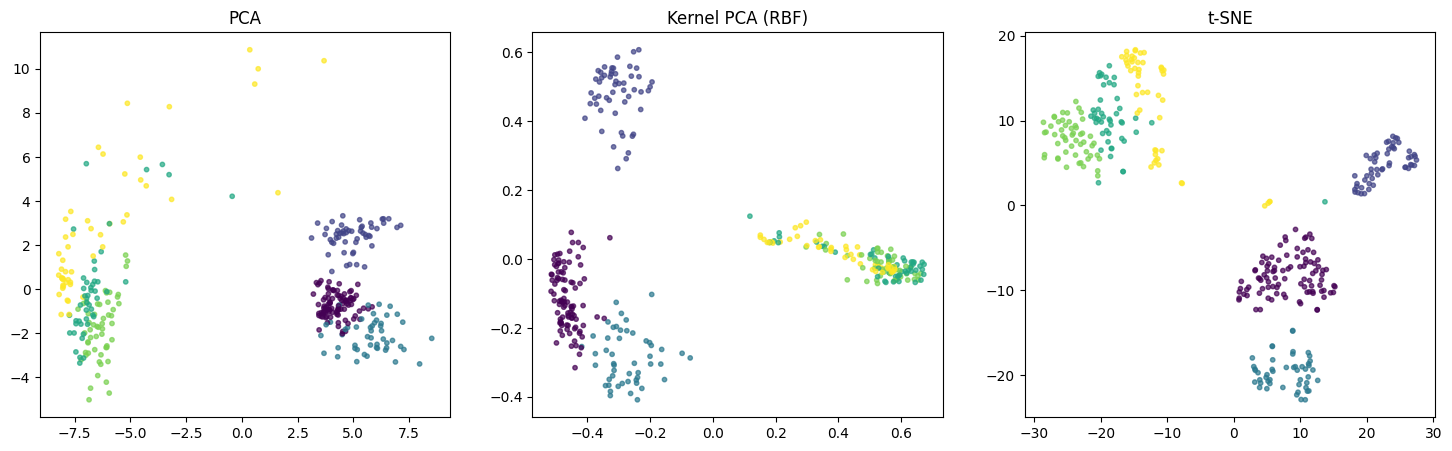

In [23]:
# --- Visualisation ---
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].scatter(X_pca[:, 0], X_pca[:, 1], s=10, alpha=0.7, c=labels_reels)
axs[0].set_title("PCA")

axs[1].scatter(X_kpca[:, 0], X_kpca[:, 1], s=10, alpha=0.7,c=labels_reels)
axs[1].set_title("Kernel PCA (RBF)")

axs[2].scatter(X_tsne[:, 0], X_tsne[:, 1], s=10, alpha=0.7, c=labels_reels)
axs[2].set_title("t-SNE")
plt.savefig('/content/drive/MyDrive/data_human_activities/pca_kpca_tsne.png')
plt.show()


### **Choix de la méthode de réduction de la dimension**

- **PCA**
  - Les groupes sont **partiellement séparés**, mais il y a un **chevauchement significatif** entre certaines classes.
  - Cela suggère que les deux premières composantes principales **ne suffisent pas** à capturer les structures discriminantes et aussi que les données **ne sont pas linéairement séparables** dans l’espace des plus fortes variances.

- **Kernel PCA (noyau RBF)**
  - La séparation est **nettement améliorée**, les clusters sont plus distincts.
  - Cela indique que la structure des données est **non linéaire**, et que l’utilisation d’un noyau permet de mieux la capturer.

- **t-SNE**
  - Les clusters sont **clairement séparés**, compacts, et bien définis, avec des frontières plus courbes.
  - Elle met en évidence les regroupements locaux sans hypothèse linéaire sur les données.

**Conclusion** : L’analyse visuelle montre que les données ne sont pas linéairement séparables. t-SNE est retenue pour l’exploration visuelle du clustering, car elle révèle des regroupements plus nets et plus compacts que les autres méthodes.

In [24]:
X_tsne.shape

(347, 2)

In [25]:
def plot_scatter_clusters(X_red, clusters, y_true, name):

    num_pred_clusters = 6
    cluster_labels = np.arange(num_pred_clusters) + 1

    # Palette unique
    cmap = plt.cm.tab10

    # Normalisation commune sur toutes les classes des deux vecteurs
    # même si y_true n'a pas 6 classes !
    norm = plt.Normalize(vmin=0, vmax=num_pred_clusters)

    fig, axes = plt.subplots(1, 2, figsize=(15, 4))

    # --- 1) Clusters prédits ---
    scatter1 = axes[0].scatter(
        X_red[:, 0], X_red[:, 1], c=norm(clusters), cmap=cmap
    )
    axes[0].set_title("Clusters prédits")
    axes[0].set_xlabel("Dim 1")
    axes[0].set_ylabel("Dim 2")

    # légende
    handles = [
        plt.Line2D([], [], marker='o', linestyle='', color=cmap(norm(lab)))
        for lab in cluster_labels
    ]
    axes[0].legend(handles, cluster_labels, title="Cluster", loc="best")

    # --- 2) Clusters originaux ---
    scatter2 = axes[1].scatter(
        X_red[:, 0], X_red[:, 1], c=norm(y_true), cmap=cmap
    )
    axes[1].set_title("Clusters originaux")
    axes[1].set_xlabel("Dim 1")
    axes[1].set_ylabel("Dim 2")

    axes[1].legend(handles, cluster_labels, title="Classe vraie", loc="best")

    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/data_human_activities/{name}.png')
    plt.show()

## **Phase 4-1 : Algorithme 1 - K-Means**

  * **Méthode :** **K-Means** (Partitionnement).
  * **Hyperparamètre $K$ :** Le nombre de clusters est fixé à **$K=6$**, ce qui correspond aux six activités humaines distinctes que nous cherchons à séparer (marche, assis, etc.).
  * **Données en entrée :** $X\_tsne$ (matrice $347 \times 2$).
  * **Sortie :** Un tableau de 347 nombres, chacun étant un label de cluster allant 1 à 6. Ce tableau représente la distribution finale des 347 fenêtres dans les 6 clusters que Kmeans a identifés.

In [26]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from matplotlib.colors import ListedColormap


In [27]:
K = 6


In [28]:
print(f"ÉTAPE 1: Entraînement du K-Means (FIT) avec K={K} (recherche des centroïdes).")

# 2a. Initialisation du modèle
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)

# 2b. Entraînement (l'algorithme trouve les 6 meilleurs centres)
kmeans.fit(X_tsne)

print("✅ Entraînement K-Means terminé.")

ÉTAPE 1: Entraînement du K-Means (FIT) avec K=6 (recherche des centroïdes).
✅ Entraînement K-Means terminé.


In [29]:
# --- 3. PREDICT : Assignation des Clusters (Obtention des Labels) ---
print(f"ÉTAPE 2: Assignation des clusters (PREDICT) à tous les 347 individus.")

# 3a. Attribution des labels (chaque point est assigné à son centroïde le plus proche)
kmeans_labels = kmeans.predict(X_tsne)

print("✅ Assignation des labels terminée.")

ÉTAPE 2: Assignation des clusters (PREDICT) à tous les 347 individus.
✅ Assignation des labels terminée.


In [30]:
print(pd.Series(kmeans_labels).value_counts().sort_index())

0    53
1    79
2    47
3    49
4    66
5    53
Name: count, dtype: int64


In [31]:
# Recalons les labels de 0–5 à 1–6
labels_1_to_6 = kmeans_labels + 1
clusters = np.unique(labels_1_to_6)


In [32]:
print("\nDistribution des individus dans les clusters K-Means :")
cluster_counts = pd.Series(labels_1_to_6).value_counts().sort_index()
print(cluster_counts)


Distribution des individus dans les clusters K-Means :
1    53
2    79
3    47
4    49
5    66
6    53
Name: count, dtype: int64


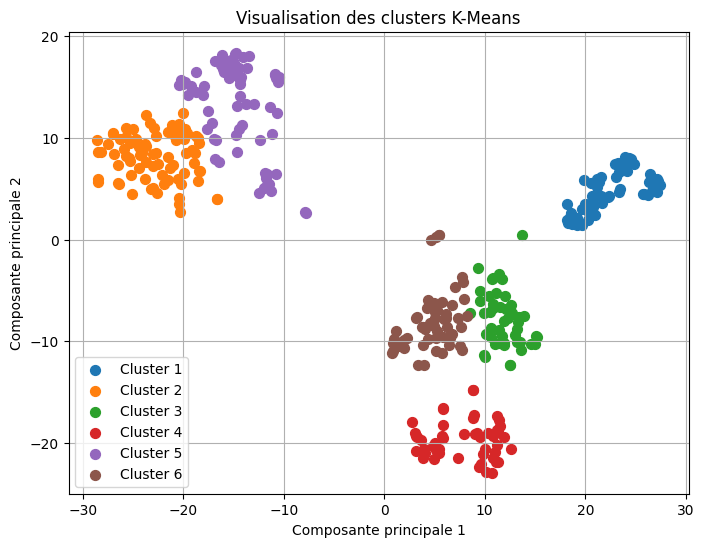

In [33]:
# Créons une palette discrète avec 6 couleurs distinctes
base_cmap = plt.colormaps.get_cmap('tab10')  # 'tab10' a 10 couleurs bien distinctes
colors = [base_cmap(i) for i in range(len(clusters))]
cmap_discret = ListedColormap(colors)

# Traçage de chaque cluster avec sa couleur
plt.figure(figsize=(8, 6))
for i, cluster in enumerate(clusters):
    plt.scatter(X_tsne[labels_1_to_6 == cluster, 0],
                X_tsne[labels_1_to_6 == cluster, 1],
                color=colors[i],
                label=f'Cluster {cluster}',
                s=50)

plt.title("Visualisation des clusters K-Means")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.legend()
plt.grid(True)
plt.savefig('/content/drive/MyDrive/data_human_activities/KMeans_Cluster_Projection_Legend.png')
plt.show()


In [34]:
# Sauvegardons les labels trouvés pour l'évaluation future
np.savetxt('/content/drive/MyDrive/data_human_activities/kmeans_labels_K6.txt', labels_1_to_6, fmt='%d')

### **Interprétation des clusters K-Means (Visuellement)**

On peut voir que :
- Les clusters sont globalement bien séparés.
- Certains groupes proches (visuellement contigus), notamment les paires de clusters (2 et 5) ainsi que (3 et 6) ne maximisent pas pleinement l’**inertie interclasse**, ce qui peut refléter des **activités similaires ou voisines**.
- Le cluster 5 apparait **plus dispersé**, suggérant une **variabilité interne** ou une **activité moins homogène**.

### **Évaluation de Kmeans**

In [35]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [36]:
# silhouette = silhouette_score(X_pca, labels_1_to_6)
# print(f"Silhouette Score : {silhouette:.3f}")

In [37]:
print("\nDistribution des vraies classes :")
print(labels_reels.value_counts())


Distribution des vraies classes :
0
1    95
5    53
2    53
6    50
3    49
4    47
Name: count, dtype: int64


In [38]:
print("Vraies classes :", labels_reels[:5])
print("Prédictions K-Means :", labels_1_to_6[:5])

Vraies classes : 0    5
1    5
2    5
3    5
4    5
Name: 0, dtype: int64
Prédictions K-Means : [2 2 2 2 2]


In [39]:
len(labels_1_to_6)

347

In [40]:
# Comparaison
ari = adjusted_rand_score(labels_reels, labels_1_to_6)
nmi = normalized_mutual_info_score(labels_reels, labels_1_to_6)

print(f"Adjusted Rand Index (ARI) : {ari:.3f}")
print(f"Normalized Mutual Information (NMI) : {nmi:.3f}")


Adjusted Rand Index (ARI) : 0.679
Normalized Mutual Information (NMI) : 0.816


#### **Interprétation des métriques d'évaluation de Kmeans**

- Un **ARI de 0.679** signifie que Kmeans est **plutôt bon**, avec une **bonne correspondance aux vraies classes**, même s’il y a quelques erreurs.  
- Un **NMI de 0.816** indique que les clusters **capturent en grande partie la structure réelle des classes**, même si les étiquettes ne sont pas exactement alignées.

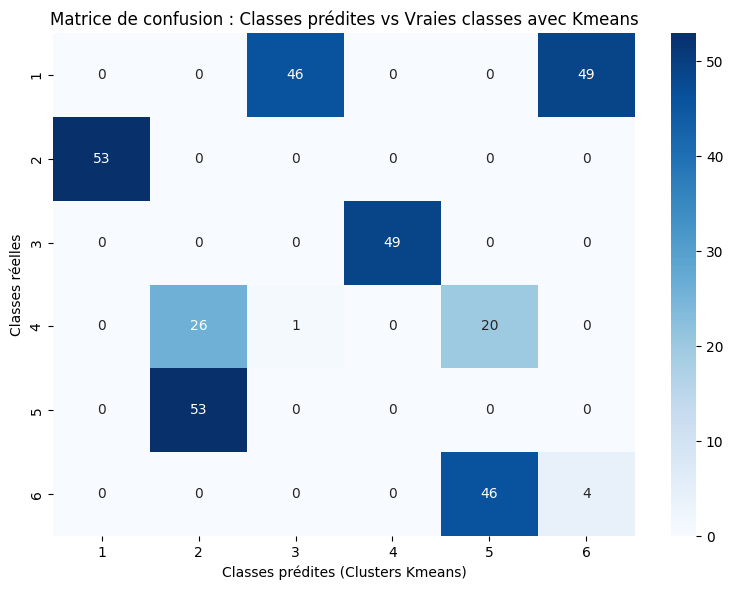

In [41]:
mat_conf = confusion_matrix(labels_reels, labels_1_to_6)

plt.figure(figsize=(8, 6))
sns.heatmap(mat_conf, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.arange(1, 7),
            yticklabels=np.arange(1, 7))
plt.title("Matrice de confusion : Classes prédites vs Vraies classes avec Kmeans")
plt.xlabel("Classes prédites (Clusters Kmeans)")
plt.ylabel("Classes réelles")
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/data_human_activities/matrice_confusion_kmeans.png')
plt.show()


#### **Interprétation de la Matrice de Confusion K-Means**

* **Marche (1)**  
  - **Mal prédite/séparée** : Aucune séparation nette.  
  - Le regroupement des 95 individus est éclaté entre deux clusters notamment le cluster 3 (46) et le cluster 6 (49), dont un partagé avec la position allongée.

* **Montée d’escaliers (2)**  
  - **Parfaitement prédite/séparée** : Tous les 53 individus sont regroupés dans le même cluster qui est le **cluster 1**, sans mélange.  
  - Ce cluster est **pur** et bien identifié.

* **Descente d’escaliers (3)**  
  - **Parfaitement prédite/séparée** : Tous les 49 individus sont regroupés dans le même cluster qui est le **cluster 4**, sans confusion.
  - Ce cluster est **pur** et bien identifié.  

* **Position assise (4)**  
  - **Mal prédite/séparée** : Les 47 individus sont répartis entre : cluster 2 (26), cluster 3 (1), cluster 5 (20)  
  - On note une forte confusion avec la **position debout** et la **position allongée**.  
  

* **Position debout (5)**  
  - **Bien regroupée** : Tous les 53 individus sont dans le **cluster 2**.  
  - Mais ce cluster contient aussi **26 individus de la position assise**, donc il n’est **pas pur**.

* **Position allongée (6)**  
  - **Partiellement prédite/séparée** : Les 50 individus sont répartis entre :cluster 5 (46), cluster 6 (4)  
  - Le **cluster 5 est majoritairement dédié à cette activité**, mais contient aussi **20 individus de la position assise**, donc il n’est **pas spécifique**.


#### **Synthèse finale**

On peut dire qu'il parvient à isoler correctement les activités dynamiques, mais échoue à distinguer les postures statiques :

- La montée et descente d’escaliers sont parfaitement regroupées dans des clusters dédiés.

- La marche est éclatée entre deux clusters, dont un partagé avec la position allongée.

- La position assise est dispersée et fortement confondue avec la position debout et allongée.

- Les clusters 2 et 5, bien qu’ils regroupent majoritairement une activité, ne sont pas spécifiques, ce qui limite leur interprétabilité.


Le modèle K-Means parvient à regrouper correctement les activités dynamiques, mais montre des limites importantes :
- Pas de garantie de séparation pertinente.
- Activités mal séparées ou confondues
- Certains clusters contiennent plusieurs classes, ce qui limite leur interprétabilité.

Ces résultats montrent que K-Means capte certaines structures fortes, mais manque de finesse pour séparer les postures proches, ce qui limite son efficacité pour une classification fiable des activités humaines.

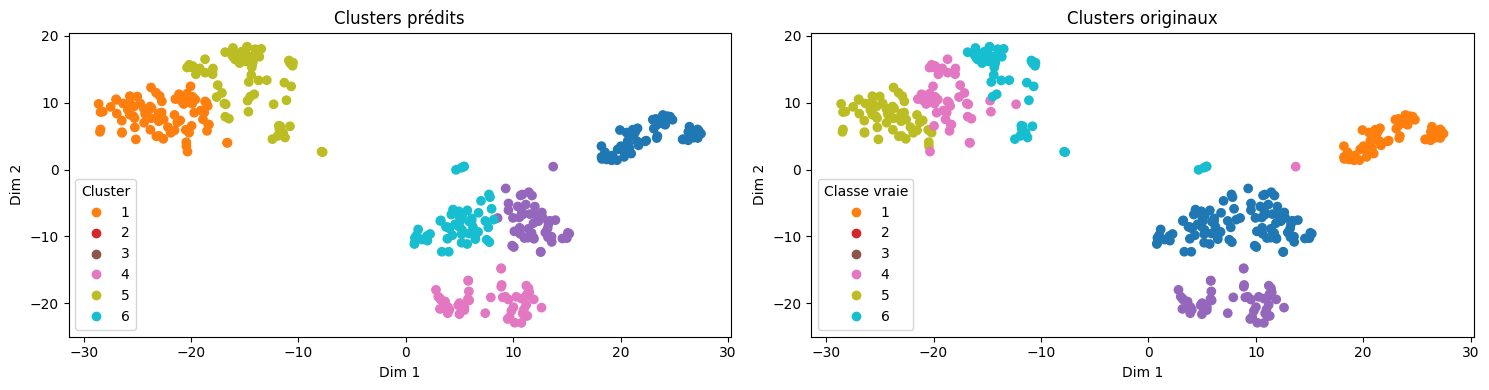

In [42]:
plot_scatter_clusters(X_tsne, labels_1_to_6, labels_reels, 'comparaison_forme_clusters_kmeans')

## **Phase 4-2 : Algorithme 2 - Classification Ascendante Hiérarchique(CAH)**

* **Méthode :** **Classification Ascendante Hiérarchique (CAH)** (Méthode Agglomérative).
* **Hyperparamètre $K$ :** Le nombre de clusters est déterminé par une **coupure du dendrogramme** à la hauteur nécessaire pour obtenir **$K=6$** clusters.
* **Données en entrée :** $X\_tsne$ ($347 \times 2$).
* **Distance d'Agrégation :** Distance Euclidienne.
* **Méthode d'Agrégation :** Méthode de Ward.
* **Sortie :** Un tableau de 347 nombres, chacun étant un label de cluster allant 1 à 6. Ce tableau représente la distribution finale des 347 fenêtres dans les 6 clusters que CAH a identifés.

L'objectif ici, est de calculer la matrice des liens hiérarchiques et de la découper pour obtenir $K=6$ classes.

In [43]:
from scipy.cluster.hierarchy import linkage, fcluster

In [44]:
K = 6

print(f"Début de l'algorithme CAH sur X_tsne ({X_tsne.shape[0]}x{X_tsne.shape[1]}).")

Début de l'algorithme CAH sur X_tsne (347x2).


In [45]:
# --- ÉTAPE 1: Calcul des liens hiérarchiques (Méthode de Ward) ---

Z_cah = linkage(X_tsne, method='ward')

In [46]:
Z_cah

array([[6.60000000e+01, 6.70000000e+01, 6.50686893e-03, 2.00000000e+00],
       [1.01000000e+02, 1.02000000e+02, 4.35617405e-02, 2.00000000e+00],
       [2.70000000e+01, 3.20000000e+01, 4.55976077e-02, 2.00000000e+00],
       ...,
       [6.83000000e+02, 6.88000000e+02, 9.54636727e+01, 1.49000000e+02],
       [6.84000000e+02, 6.90000000e+02, 1.94684201e+02, 2.02000000e+02],
       [6.89000000e+02, 6.91000000e+02, 4.63186397e+02, 3.47000000e+02]])

In [47]:
# --- ÉTAPE 2: Découpage de l'arbre Z pour obtenir 6 clusters. ---
# criterion='maxclust' : permet de découper le dendrogramme de manière à obtenir un nombre maximum de clusters prédéfini.
cah_labels = fcluster(Z_cah, K, criterion='maxclust')

In [48]:
cah_labels[:5]

array([1, 1, 1, 1, 1], dtype=int32)

In [49]:
print("\nDistribution des individus dans les classes formées par CAH (K=6):")
cluster_counts_cah = pd.Series(cah_labels).value_counts().sort_index()
print(cluster_counts_cah)


Distribution des individus dans les classes formées par CAH (K=6):
1    87
2    58
3    53
4    49
5    46
6    54
Name: count, dtype: int64


In [50]:
# Sauvegardons les labels trouvés pour l'évaluation future
np.savetxt('/content/drive/MyDrive/data_human_activities/cah_labels_K6_dim10.txt', cah_labels, fmt='%d')

In [51]:
from scipy.cluster.hierarchy import dendrogram

In [52]:
Z_cah.shape
#Taille : (346,4) (346 fusions, car il y a N-1 fusions pour N=347 individus).

(346, 4)

In [53]:
print(Z_cah[:5])

[[6.60000000e+01 6.70000000e+01 6.50686893e-03 2.00000000e+00]
 [1.01000000e+02 1.02000000e+02 4.35617405e-02 2.00000000e+00]
 [2.70000000e+01 3.20000000e+01 4.55976077e-02 2.00000000e+00]
 [1.25000000e+02 1.26000000e+02 5.17101446e-02 2.00000000e+00]
 [3.90000000e+01 2.26000000e+02 6.34204062e-02 2.00000000e+00]]


In [54]:
N = X_tsne.shape[0]

# Calcul de la distance de coupure : Hauteur de la (N-K)ème fusion
# La colonne avec l'index 2 (Z_cah[...., 2]) contient la distance à laquelle cette fusion s'est produite.
# Par conséquent, Z_cah[341, 2] nous donne la distance exacte qui est le seuil de coupure pour obtenir 6 clusters.
cut_distance = Z_cah[N - K, 2]

print(f"La distance de coupure calculée pour K={K} (N={N}) est : {cut_distance:.4f}")

La distance de coupure calculée pour K=6 (N=347) est : 47.2681


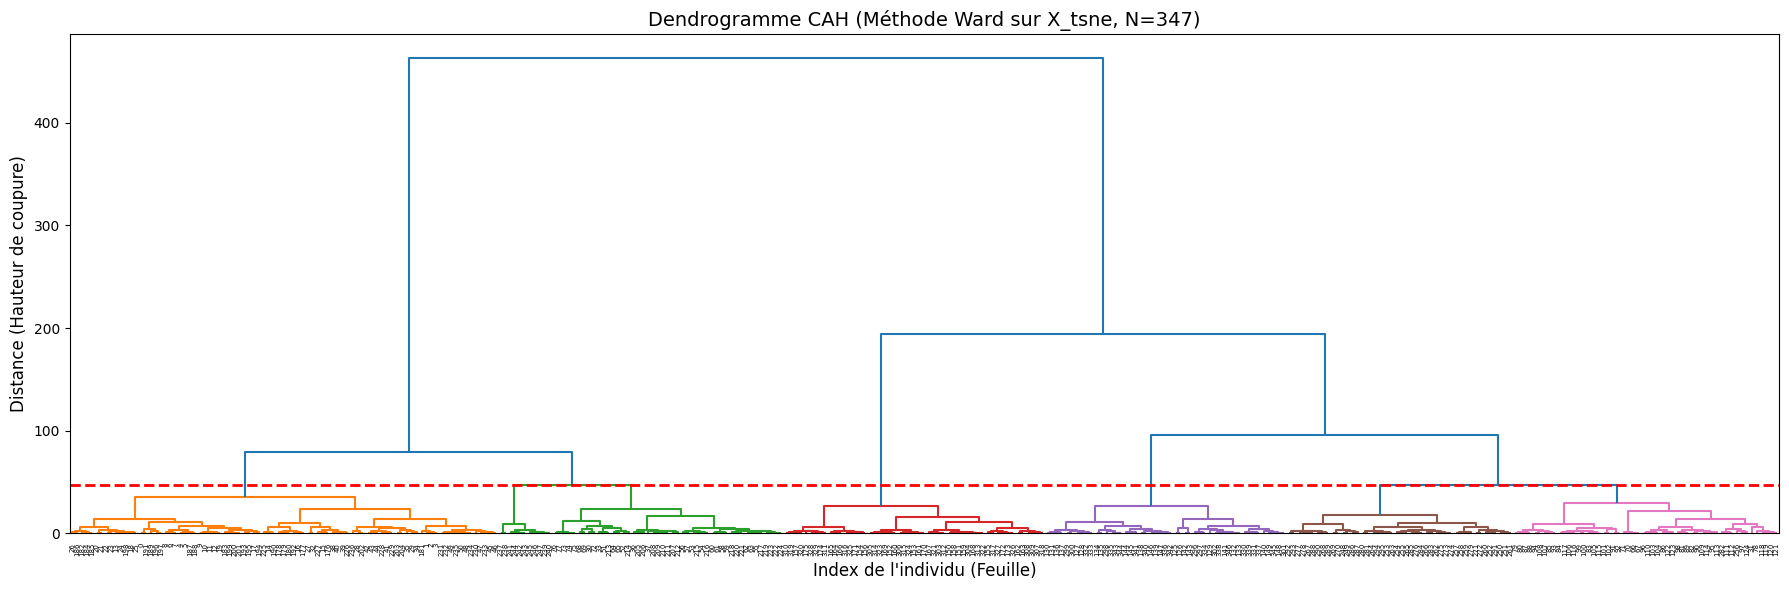

In [55]:
# --- ÉTAPE 3 : VISUALISATION DU DENDROGRAMME ---

plt.figure(figsize=(18, 6))

# sans troncature
dendrogram(Z_cah,
           color_threshold=cut_distance, # Colore les 6 branches
           truncate_mode='none',
           show_leaf_counts=True,
           leaf_rotation=90., # Rotation des étiquettes des feuilles
           leaf_font_size=5.,
           show_contracted=False)

# Ajout de la ligne horizontale pour visualiser le niveau de coupure
plt.axhline(y=cut_distance, color='r', linestyle='--', linewidth=2, label=f'Coupure (K={K})')

plt.title(f'Dendrogramme CAH (Méthode Ward sur X_tsne, N={N})', fontsize=14)

plt.xlabel("Index de l'individu (Feuille)", fontsize=12)
plt.ylabel('Distance (Hauteur de coupure)', fontsize=12)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/data_human_activities/CAH_Dendrogram.png')
plt.show()

### **Évaluation de la CAH**

In [56]:
ari_cah = adjusted_rand_score(labels_reels, cah_labels)
nmi_cah = normalized_mutual_info_score(labels_reels, cah_labels)

print("\n--- Métriques d'Évaluation CAH vs Vrais Labels ---")
print(f"Adjusted Rand Index (ARI) : {ari_cah:.3f}")
print(f"Normalized Mutual Information (NMI) : {nmi_cah:.3f}")


--- Métriques d'Évaluation CAH vs Vrais Labels ---
Adjusted Rand Index (ARI) : 0.684
Normalized Mutual Information (NMI) : 0.822


#### **Interprétation des métriques d'évaluation de CAH**

La Classification Ascendante Hiérarchique (CAH) obtient des scores **plus élevés** que K-Means sur les deux métriques d’évaluation externe :

- **ARI (Adjusted Rand Index)** :  
  - CAH : **0.684** vs K-Means : **0.679**  
  - Cela signifie que la partition produite par la CAH correspond davantage aux vraies classes d’activité.

- **NMI (Normalized Mutual Information)** :  
  - CAH : **0.822** vs K-Means : **0.816**  
  - Un score plus élevé indique que la structure informative des vraies classes est mieux conservée.

Ces résultats suggèrent que la CAH, avec la méthode de Ward, **reproduit plus fidèlement la structure réelle des activités** que K-Means, malgré une différence modérée.

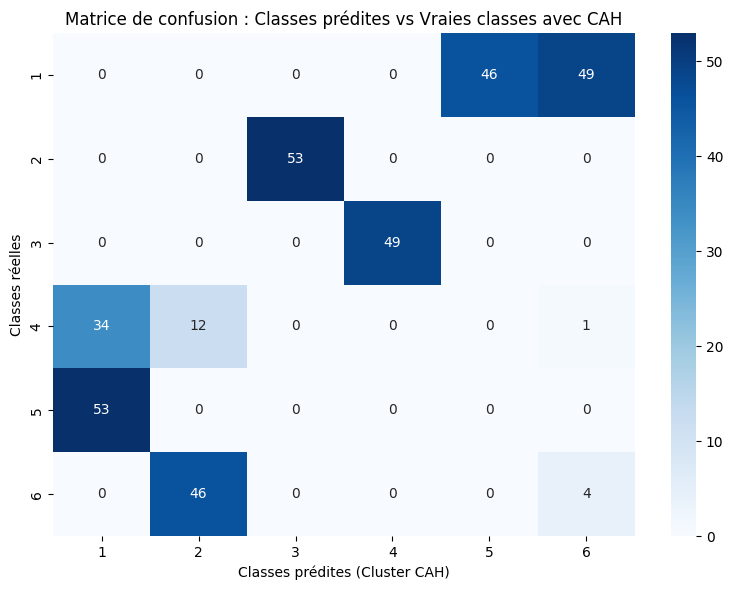

In [57]:

# --- CALCUL DE LA MATRICE DE CONFUSION ---

mat_conf_cah = confusion_matrix(labels_reels, cah_labels)

# --- VISUALISATION DE LA MATRICE DE CONFUSION ---

plt.figure(figsize=(8, 6))
sns.heatmap(mat_conf_cah, annot=True, fmt='d', cmap='Blues',
            # Les labels sont 1-6
            xticklabels=np.arange(1, 7),
            yticklabels=np.arange(1, 7))
plt.title("Matrice de confusion : Classes prédites vs Vraies classes avec CAH", fontsize=12)
plt.xlabel("Classes prédites (Cluster CAH)", fontsize=10)
plt.ylabel("Classes réelles", fontsize=10)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/data_human_activities/cah_matrice_confusion.png')
plt.show()

#### **Interprétation de la matrice de confusion de la CAH**

* **Marche (1)**  
  - **Mal prédite/séparée** : Les 95 individus sont répartis entre **cluster 5 (46)** et **cluster 6 (49)**.  
  - Aucune séparation nette, et confusion avec la **position allongée**, également présente dans le cluster 6.  
  - Ce type de confusion avait déjà été observé avec K-Means, ce qui suggère une **proximité dynamique difficile à dissocier**.

* **Montée d’escaliers (2)** et **Descente d’escaliers (3)**  
  - **Parfaitement prédite/séparée** : Comme avec K-Means, ces deux activités sont **clairement isolées**, ce qui confirme leur **structure bien définie et facilement captée** par les algorithmes.

* **Position assise (4)** et **Position debout (5)**  
  - **Mal prédite/séparée** : Les 47 individus de la position assise sont répartis entre :
    - **cluster 1 (34)**, partagé avec les 53 individus de la position debout
    - **cluster 2 (12)**, partagé avec la position allongée
    - **cluster 6 (1)**  
  - Cette confusion entre postures statiques était déjà présente chez K-Means, mais ici elle est **plus concentrée**, ce qui montre que la CAH **tend à fusionner les postures proches plutôt qu’à les disperser**.

* **Position allongée (6)**  
  - **Partiellement prédite/séparée** : Les 50 individus sont répartis entre :
    - **cluster 2 (46)**, qui contient aussi 12 individus de la position assise
    - **cluster 6 (4)**, qui contient aussi 49 individus de la marche
  - La position allongée est donc confondue à la fois avec la **posture assise** et avec la **marche**, ce qui rend son interprétation particulièrement difficile et limite la spécificité du cluster.
  - Ce type de fusion entre **statique** et **dynamique** n’était pas observé avec K-Means, et montre que la CAH tend à regrouper des profils très différents dès lors qu’ils partagent des caractéristiques globales.



#### **Synthèse finale**

La CAH parvient à **isoler efficacement les activités dynamiques bien structurées**, comme la **montée** et la **descente d’escaliers**, confirmant la **bonne séparation déjà observée avec K-Means**.  
En revanche, elle **échoue à distinguer les postures statiques**, notamment la **position assise**, qui reste **confondue avec la position debout et allongée**, comme c’était déjà le cas avec K-Means.  
La **position allongée**, bien que majoritairement regroupée, est **simultanément confondue avec la marche**, ce qui introduit une **fusion entre dynamique et statique** absente chez K-Means.  
Quant à la **marche**, elle est **toujours éclatée entre deux clusters**, ce qui montre que **ni K-Means ni CAH ne parviennent à l’isoler clairement**.

En résumé, la CAH **réduit la dispersion** observée chez K-Means pour certaines classes, mais **accentue parfois la fusion entre activités proches**, ce qui améliore la **cohérence interne des regroupements** sans garantir leur **spécificité**.

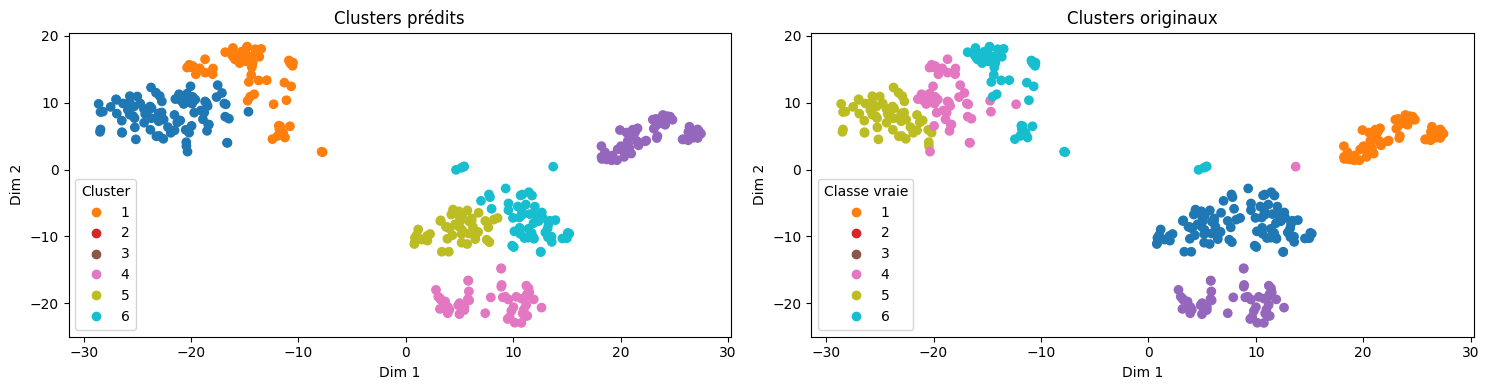

In [58]:
plot_scatter_clusters(X_tsne, cah_labels, labels_reels, 'cah_comparaison_forme_clusters')

## **Phase 4-3 : Algorithme 3 - Clustering Spectral**

* **Méthode :** **Clustering Spectral** (Basé sur la Théorie des Graphes et les valeurs propres).
* **Hyperparamètres** :  
  - **$K$ :** Le nombre de clusters est fixé à **$K=6$**, pour les $6$ activités.
  - **Affinity** : Pour construire la matrice de similarité dans l'espace 2D.
    - **Choix** : **RBF** (Radial Basis Function).
* **Données en entrée :** $X\_tsne$ (matrice $347 \times2$).
* **Sortie :** Un tableau de 347 nombres, chacun étant un label de cluster allant 1 à 6. Ce tableau représente la distribution finale des 347 fenêtres dans les 6 clusters que le clustering spectral a identifés.


In [59]:
from sklearn.cluster import SpectralClustering

In [60]:
K = 6

In [61]:
# Initialisation du modèle
spectral_model = SpectralClustering(
    n_clusters=K,
    affinity='rbf',
    random_state=42,
    n_init=10
)

In [62]:
spectral_model

SpectralClustering(n_clusters=6, random_state=42)

In [63]:
# Entraînement (FIT) et Prédiction (PREDICT)
spectral_labels_0_based = spectral_model.fit_predict(X_tsne)

In [64]:
spectral_labels_0_based[:5]

array([0, 0, 0, 0, 0], dtype=int32)

In [65]:
# Ajustement des labels à 1-basés (1 à 6) pour la cohérence de l'évaluation
spectral_labels = spectral_labels_0_based + 1
spectral_labels[:5]

array([1, 1, 1, 1, 1], dtype=int32)

In [66]:
print("\nDistribution des individus dans les 6 classes formées par Clustering Spectral:")
cluster_counts_spectral = pd.Series(spectral_labels).value_counts().sort_index()
print(cluster_counts_spectral)


Distribution des individus dans les 6 classes formées par Clustering Spectral:
1    187
2      2
3      4
4     96
5     49
6      9
Name: count, dtype: int64


In [67]:
# Sauvegardons les labels trouvés (Labels 1-6)
np.savetxt('/content/drive/MyDrive/data_human_activities/spectral_labels_K6_dim2.txt', spectral_labels, fmt='%d')


In [68]:
from sklearn.manifold import TSNE

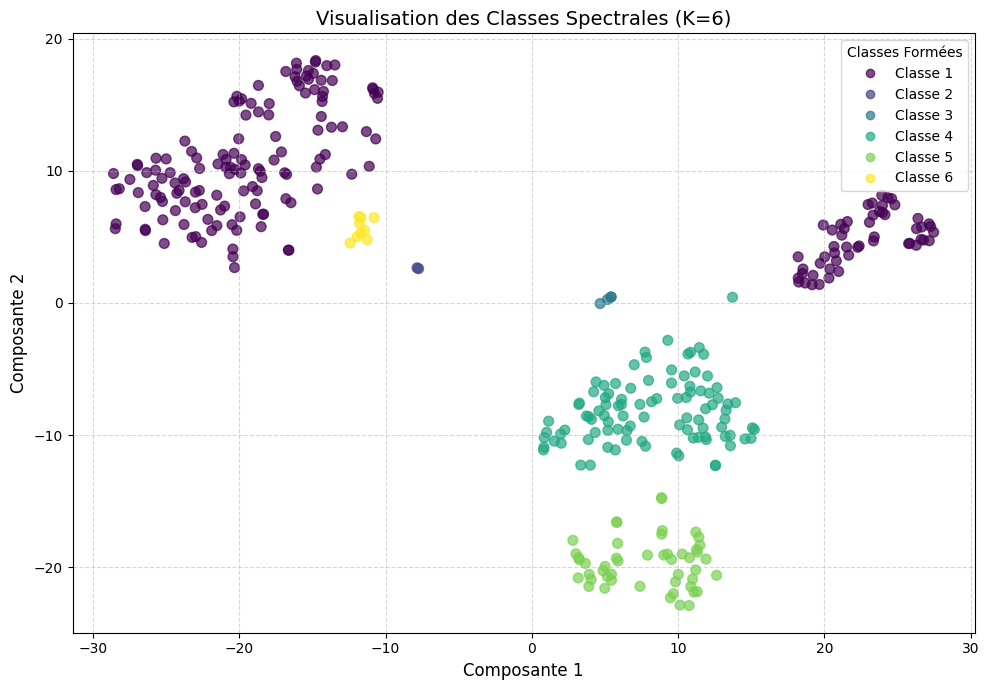

In [69]:
K = 6
X_plot = X_tsne

# --- VISUALISATION DES CLASSES FORMÉES ---
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_plot[:, 0], # Composante t-SNE 1 (Axe X)
    X_plot[:, 1], # Composante t-SNE 2 (Axe Y)
    c=spectral_labels, # Couleur basée sur le label de cluster (1 à 6)
    cmap='viridis',
    s=50,
    alpha=0.7
)

# Configuration des labels et du titre
plt.title(f'Visualisation des Classes Spectrales (K={K})', fontsize=14)
plt.xlabel(f'Composante 1', fontsize=12)
plt.ylabel(f'Composante 2', fontsize=12)
plt.legend(
    handles=scatter.legend_elements()[0],
    labels=[f'Classe {i}' for i in range(1, K + 1)],
    title="Classes Formées",
    loc='best'
)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/data_human_activities/Spectral_Cluster_Projection.png')
plt.show()

### **Interprétation clustering spectral (Visuellement)**

On peut voir que :
- Le clustering spectral parvient à séparer les classes, avec des groupes globalement distincts dans l’espace réduit.
- L’**inertie intra-classe n’est pas parfaitement minimisée** : les classes spectrales sont **peu concentrées**, ce qui reflète une **variabilité interne**.
- La **classe spectrale 1** présente une **séparation imparfaite**, avec deux sous-groupes visuellement distincts, suggérant une **activité composite (pourrait masquer deux activités) ou mal segmentée**.
- Les **classes spectrales 4 et 5** adoptent des **formes courbes**, tandis que la **classe spectrale 1** est **allongée** : ces géométries peuvent refléter des **activités dynamiques** (marche, escaliers) qui suivent un **cycle ou une trajectoire** dans l’espace des caractéristiques.
- Certaines classes spectrales sont **nettement plus denses que d’autres**, ce qui peut indiquer des **activités plus homogènes ou plus fréquentes**.

### **Évaluation du clustering spectral**

In [70]:
# Calcul Spectral Clustering (sur X_tsne_2)
ari_spectral = adjusted_rand_score(labels_reels, spectral_labels)
nmi_spectral = normalized_mutual_info_score(labels_reels, spectral_labels)

print("\n--- Métriques d'Évaluation Clustering spectral vs Vrais Labels ---")
print(f"Adjusted Rand Index (ARI) : {ari_spectral:.3f}")
print(f"Normalized Mutual Information (NMI) : {nmi_spectral:.3f}")


--- Métriques d'Évaluation Clustering spectral vs Vrais Labels ---
Adjusted Rand Index (ARI) : 0.464
Normalized Mutual Information (NMI) : 0.690


#### **Interprétation des métriques d’évaluation du Clustering Spectral**

Le clustering spectral obtient des scores **nettement inférieurs** à ceux de K-Means et de la CAH sur les deux métriques externes :

- **ARI (Adjusted Rand Index)** :  
  - Spectral : **0.464**  
  - Ce score indique une **faible concordance** entre les clusters produits et les vraies classes. Le modèle **ne parvient pas à reproduire fidèlement les regroupements réels**, avec de nombreuses erreurs d’appariement.

- **NMI (Normalized Mutual Information)** :  
  - Spectral : **0.690**  
  - Bien que ce score reste modérément élevé, il est **significativement plus bas** que ceux obtenus par K-Means (0.816) et CAH (0.822). Cela suggère que la **structure informative globale est partiellement captée**, mais avec **moins de précision**.




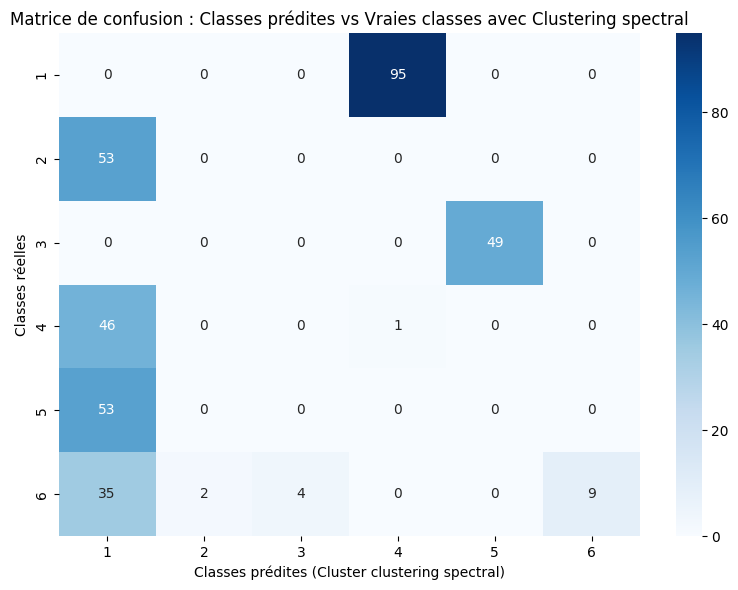

In [71]:

# --- CALCUL DE LA MATRICE DE CONFUSION ---

mat_conf_spec = confusion_matrix(labels_reels, spectral_labels)

# --- VISUALISATION DE LA MATRICE DE CONFUSION ---

plt.figure(figsize=(8, 6))
sns.heatmap(mat_conf_spec, annot=True, fmt='d', cmap='Blues',
            # Les labels sont 1-6
            xticklabels=np.arange(1, 7),
            yticklabels=np.arange(1, 7))
plt.title("Matrice de confusion : Classes prédites vs Vraies classes avec Clustering spectral", fontsize=12)
plt.xlabel("Classes prédites (Cluster clustering spectral)", fontsize=10)
plt.ylabel("Classes réelles", fontsize=10)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/data_human_activities/spec_matrice_confusion.png')
plt.show()

#### **Interprétation activité par activité**

- **Montée d’escaliers (2)**  
  - **Mal prédite/séparée** : les 53 individus sont dans le **cluster 1**, mais ce cluster contient aussi : 46 individus de la position assise, 53 individus de la position debout, 35 individus de la position allongée  
  - Le cluster 1 est **massivement partagé** entre quatre classes.  
  - Contrairement à ce qu’on observe chez K-Means et CAH, la montée d’escaliers **n’est pas isolée ici**, malgré le regroupement complet des 53 individus.

- **Marche (1)**  
  - **Partiellement bien prédite/séparée** : les 95 individus sont dans le **cluster 4**, mais ce cluster contient aussi **1 individu de la position assise**.  
  - Le regroupement est **majoritaire**, mais le cluster est **partagé**, donc **pas pur**.

- **Descente d’escaliers (3)**  
  - **Parfaitement regroupée** : les 49 individus sont tous dans le **cluster 5**, sans mélange, ce cluster est pur.  
  - Même performance que K-Means et CAH.

- **Position assise (4)**  
  -  **Mal prédite/séparée** : les 47 individus sont répartis entre :
    - **cluster 1 (46)** qui est partagé avec montée, debout, allongée  
    - **cluster 4 (1)** qui est partagé avec marche  
  - Donc on note une **forte** confusion avec plusieurs activités, notamment **debout et montée**, dans le cluster 1.

- **Position debout (5)**  
  - **Mal prédite/séparée** : les 53 individus sont tous dans le **cluster 1**, partagé avec assise, montée et allongée.  
  - Le cluster est **massivement fusionné**, donc **non interprétable**.

- **Position allongée (6)**  
  - **Très mal prédite/séparée** : les 50 individus sont répartis entre 04 clusters :
    - **cluster 1 (35)** qui est partagé avec trois autres classes  
    - **cluster 2 (2)**, **cluster 3 (4)**, **cluster 6 (9)**  
  - On note une **confusion avec des postures statiques et dynamiques**.  
  - C’est l’activité **la plus éclatée** dans ce modèle.


#### **Synthèse finale**

- Le clustering spectral **échoue à isoler presque toutes les activités**, y compris celles qui étaient bien captées par K-Means et CAH.   
- La **marche** est mieux regroupée que dans les autres modèles, mais le cluster reste **partagé**.  
- La **descente d’escaliers** est la **seule activité parfaitement isolée**.  
- Les **postures statiques** (assise, debout, allongée) sont **confondues ou éclatées**, avec une **fusion extrême dans le cluster 1**.

Ces résultats viennent confirmer les scores ARI (0.464) et NMI (0.690) obtenus plus haut. Le clustering spectral échoue globalement à reproduire fidèlement la structure réelle des activités humaines.



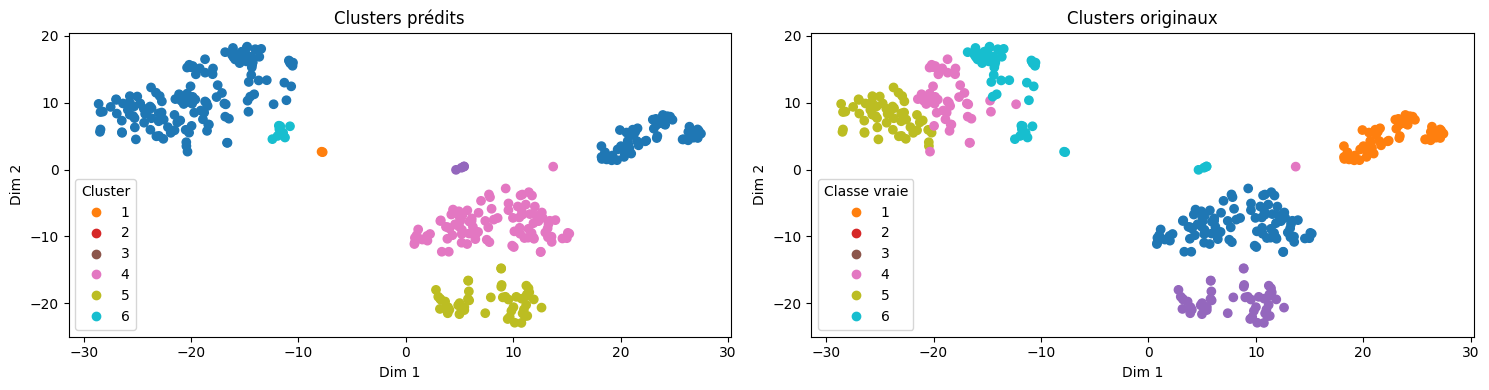

In [72]:
plot_scatter_clusters(X_tsne, spectral_labels, labels_reels, 'spectral_comparaison_forme_clusters')

## **Comparaison des trois modèles de clustering**

#### **Récapitulatif**

| Activité | K-Means | CAH (Ward) | Spectral |
|----------|---------|------------|----------|
| **Marche (1)** | Éclatée entre 02 clusters, confusion avec allongée | Pareil que K-Means | Regroupée presque entièrement, mais partagée avec assise |
| **Montée (2)** | Parfaitement isolée | Parfaitement isolée | Regroupée mais fusionnée avec assise, debout et allongée |
| **Descente (3)** | Parfaitement isolée | Parfaitement isolée | Parfaitement isolée |
| **Assise (4)** | Dispersée, confusion avec debout et allongée | Pareil que K-Means, mais la confusion est plus concentrée | Fusionnée totalement avec debout, montée et allongée |
| **Debout (5)** | Regroupée mais mélangée avec assise | Pareil que K-Means| Fusionnée totalement avec assise, montée et allongée |
| **Allongée (6)** | Majoritairement regroupée mais mélangée avec assise | Pareil que K-Means, mais en plus mélangée avec la marche | Très mal prédite, éclatée dans plusieurs clusters et mélangée avec assise, debout et montée |



#### **Synthèse comparative**

| Modèle | Points forts | Limites |
|--------|--------------|---------|
| **K-Means** | Montée et descente bien isolées | Marche éclatée, assise et debout confondues, allongée partiellement mélangée |
| **CAH (Ward)** | Montée et descente bien isolées, marche mieux regroupée que K-Means | Assise et debout confondues, allongée mélangée avec assise et marche |
| **Spectral** | Descente bien isolée, marche mieux regroupée que K-Means/CAH | Montée fusionnée avec plusieurs classes, assise et debout totalement confondues, allongée éclatée sur plusieurs clusters |

## **Conclusion - Choix du modèle**

Il était question ici de comparer différentes méthodes de clustering afin d’évaluer leur capacité à restituer la structure réelle des différentes activités. Il en ressort que, malgré des performances globalement proches, toutes les approches (sauf pas totalement pour une) parviennent à isoler les activités dynamiques, tandis que les postures statiques demeurent plus difficiles à séparer.

Au vu des résultats, la méthode **hiérarchique par Ward** apparaît comme la plus pertinente car, elle parvient à mieux distinguer les regroupements que les autres, même si certaines confusions persistent. Ce modèle n’est pas parfait et présente des limites, mais il offre la séparation la plus cohérente. Ce choix est confirmé par ses scores d’évaluation (ARI et NMI), qui sont les plus élevés parmi les modèles testés, traduisant une meilleure fidélité à la structure réelle des données.

## **Recommandations et perspectives**

L’analyse a montré que les méthodes de clustering testées n’ont pas permis de séparer de manière satisfaisante l’ensemble des activités, en particulier les postures statiques. Plusieurs pistes d’amélioration peuvent être envisagées :

- **Réduction du nombre de caractéristiques extraites** : bien que l’ensemble des caractéristiques extraites proposées ait été utilisé, il serait pertinent de limiter leur nombre afin de ne conserver que les plus discriminantes.
- **Méthodes de réduction de dimension plus adaptées** :
  - **Kernel PCA** avec noyau RBF
  - **UMAP** qui peut mieux préserver les structures globales et locales, là où les approches actuelles n’ont pas réussi à modéliser correctement les frontières entre classes.  
- **Algorithmes de clustering alternatifs** :
    - HDBSCAN, permettant de détecter des sous‑structures ou de traiter certaines activités dispersées comme du bruit.
    - **Consensus clustering** : combiner plusieurs partitions issues de différents algorithmes (K‑Means, CAH, Spectral) afin d’obtenir une solution plus robuste et tirer parti des forces de chaque méthode.
- **Évaluation complémentaire** : compléter l’analyse par des métriques internes (Silhouette, ...) pour juger la cohérence des clusters indépendamment des labels, et comparer la stabilité des résultats sur plusieurs projections.
